In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [2]:
conn = sqlite3.connect("/content/sample_data/database.sqlite")

In [3]:
query = """
SELECT *
FROM Superstore
LIMIT 5;
"""

df = pd.read_sql_query(query, conn)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1.0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2.0,0.00,41.9136
1,2.0,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3.0,0.00,219.5820
2,3.0,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2.0,0.00,6.8714
3,4.0,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5.0,0.45,-383.0310
4,5.0,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2.0,0.20,2.5164


In [6]:
query = """
SELECT
    Category,
    SUM(Sales) AS Total_Sales
FROM Superstore
GROUP BY Category
ORDER BY Total_Sales DESC;
"""


category_sales = pd.read_sql_query(query, conn)

category_sales

,Category,Total_Sales
0,Technology,836154.0330
1,Furniture,741999.7953
2,Office Supplies,719047.0320


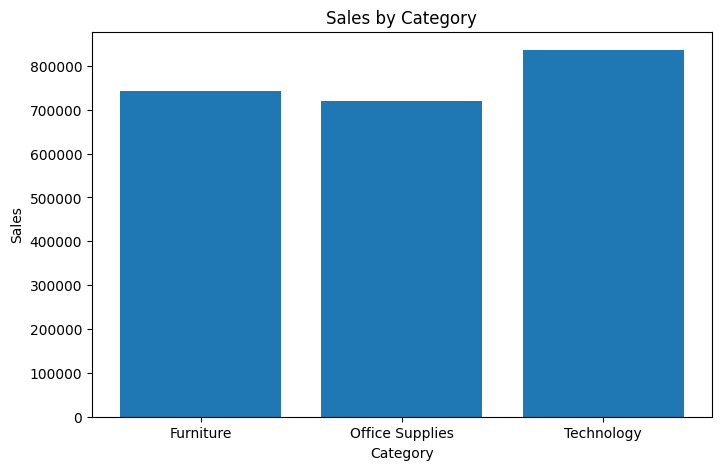

In [4]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt

conn = sqlite3.connect("/content/sample_data/database.sqlite")

query = """
SELECT
Category,
SUM(Sales) AS Total_Sales
FROM Superstore
GROUP BY Category;
"""

df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))
plt.bar(df["Category"], df["Total_Sales"])
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

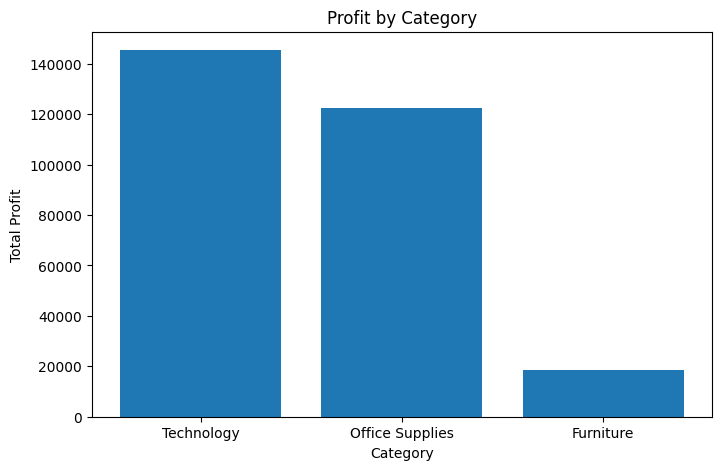

In [7]:
query = """
SELECT
    Category,
    ROUND(SUM(Profit),2) AS Total_Profit
FROM Superstore
GROUP BY Category
ORDER BY Total_Profit DESC;
"""

profit_category = pd.read_sql_query(query, conn)
profit_category

plt.figure(figsize=(8,5))

plt.bar(profit_category["Category"],
        profit_category["Total_Profit"])

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")

plt.show()

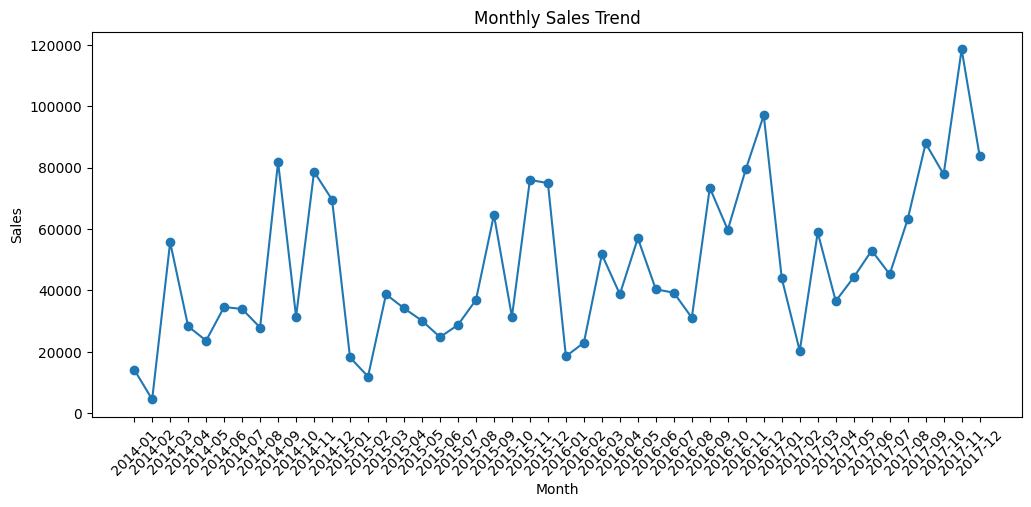

In [34]:
query = """
SELECT
    "Order Date",
    Sales
FROM Superstore;
"""

monthly_sales = pd.read_sql_query(query, conn)

# Convert to datetime
monthly_sales["Order Date"] = pd.to_datetime(
    monthly_sales["Order Date"]
)

# Create Month column
monthly_sales["Month"] = monthly_sales["Order Date"].dt.strftime("%Y-%m")

# Aggregate
monthly_sales = (
    monthly_sales
    .groupby("Month", as_index=False)["Sales"]
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_sales["Month"],
    monthly_sales["Sales"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")

plt.show()

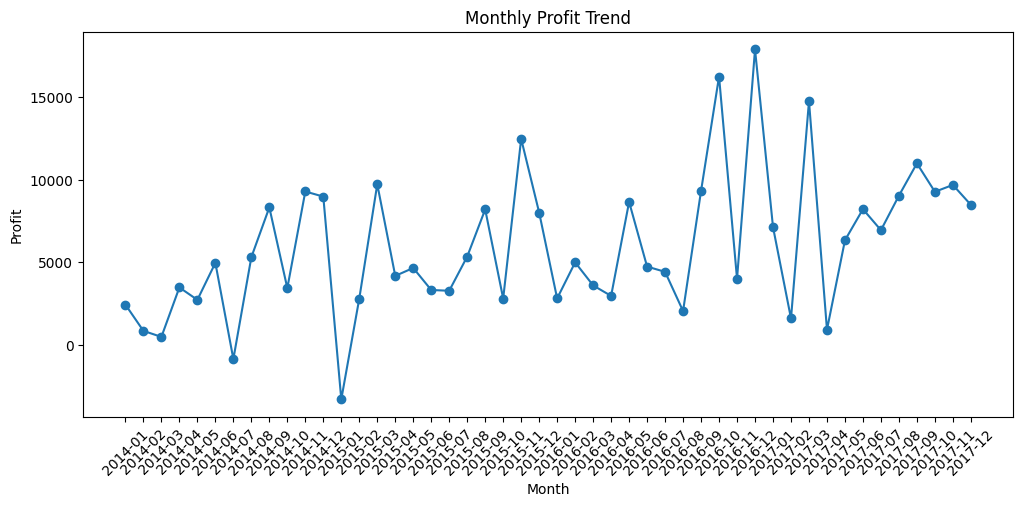

In [35]:
query = """
SELECT
    "Order Date",
    Profit
FROM Superstore;
"""

monthly_profit = pd.read_sql_query(query, conn)

monthly_profit["Order Date"] = pd.to_datetime(
    monthly_profit["Order Date"]
)

monthly_profit["Month"] = monthly_profit["Order Date"].dt.strftime("%Y-%m")

monthly_profit = (
    monthly_profit
    .groupby("Month", as_index=False)["Profit"]
    .sum()
)

plt.figure(figsize=(12,5))

plt.plot(
    monthly_profit["Month"],
    monthly_profit["Profit"],
    marker="o"
)

plt.xticks(rotation=45)

plt.title("Monthly Profit Trend")
plt.xlabel("Month")
plt.ylabel("Profit")

plt.show()

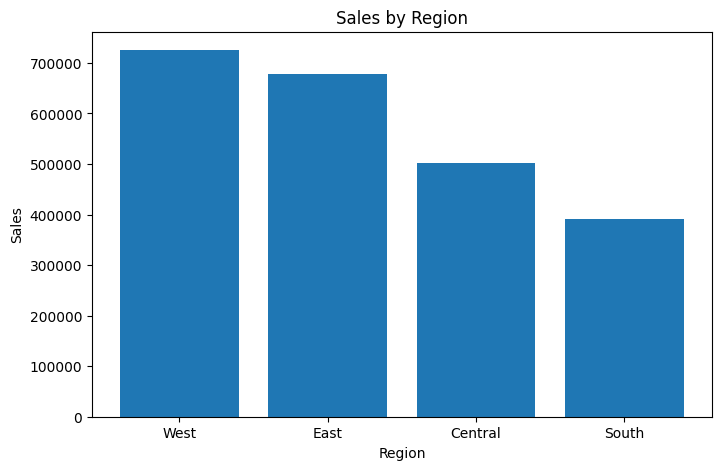

In [14]:
query = """
SELECT
    Region,
    ROUND(SUM(Sales),2) AS Sales
FROM Superstore
GROUP BY Region
ORDER BY Sales DESC;
"""

sales_region = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.bar(sales_region["Region"],
        sales_region["Sales"])

plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

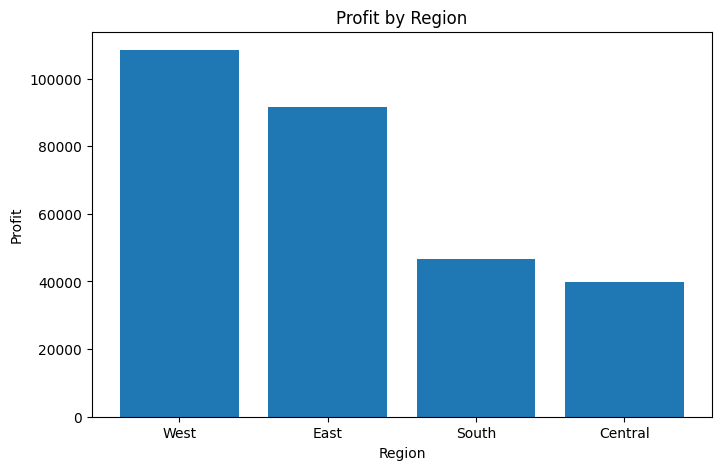

In [16]:
query = """
SELECT
    Region,
    ROUND(SUM(Profit),2) AS Profit
FROM Superstore
GROUP BY Region
ORDER BY Profit DESC;
"""

profit_region = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.bar(profit_region["Region"],
        profit_region["Profit"])

plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")

plt.show()


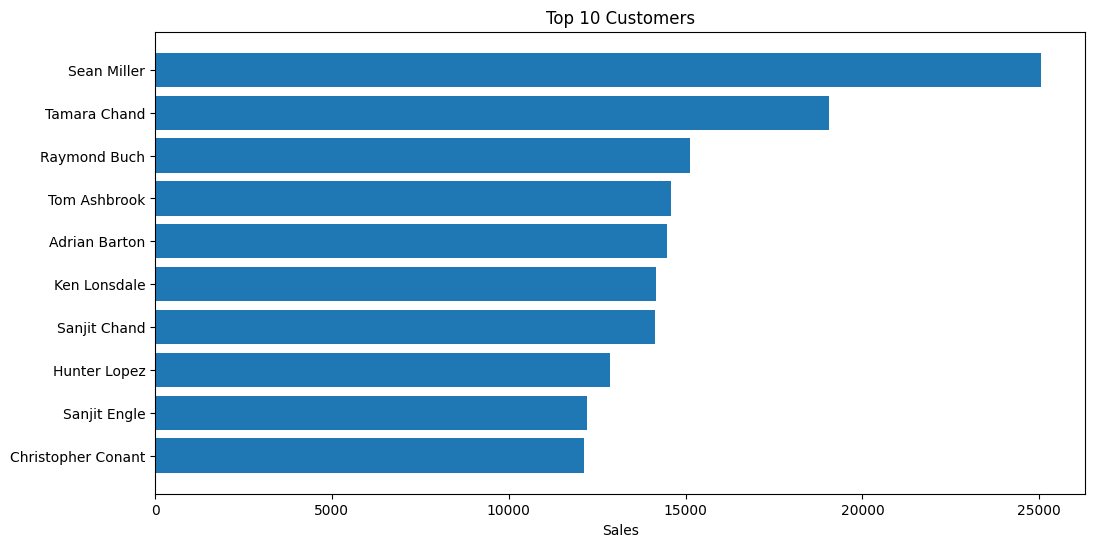

In [23]:
query = """
SELECT
    "Customer Name",
    ROUND(SUM(Sales),2) AS Sales
FROM Superstore
GROUP BY "Customer Name"
ORDER BY Sales DESC
LIMIT 10;
"""

top_customers = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))

plt.barh(top_customers["Customer Name"],
         top_customers["Sales"])

plt.title("Top 10 Customers")
plt.xlabel("Sales")

plt.gca().invert_yaxis()

plt.show()

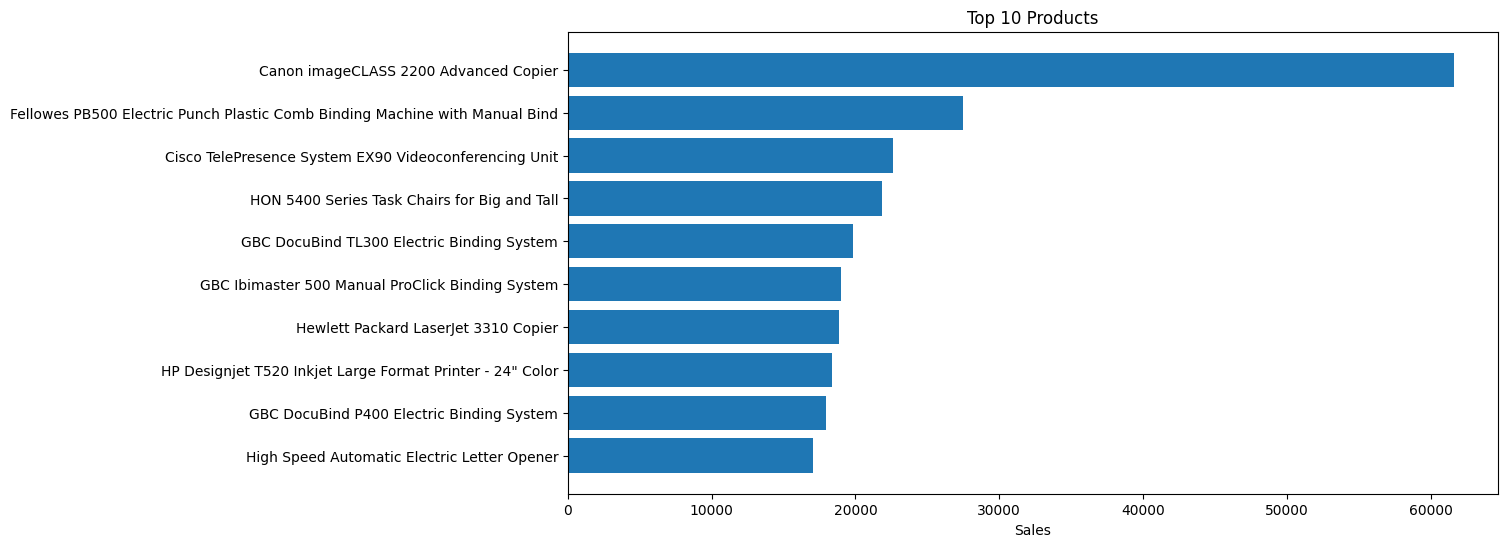

In [22]:
query = """
SELECT
    "Product Name",
    ROUND(SUM(Sales),2) AS Sales
FROM Superstore
GROUP BY "Product Name"
ORDER BY Sales DESC
LIMIT 10;
"""

top_products = pd.read_sql_query(query, conn)

plt.figure(figsize=(12,6))

plt.barh(top_products["Product Name"],
         top_products["Sales"])

plt.title("Top 10 Products")
plt.xlabel("Sales")

plt.gca().invert_yaxis()

plt.show()

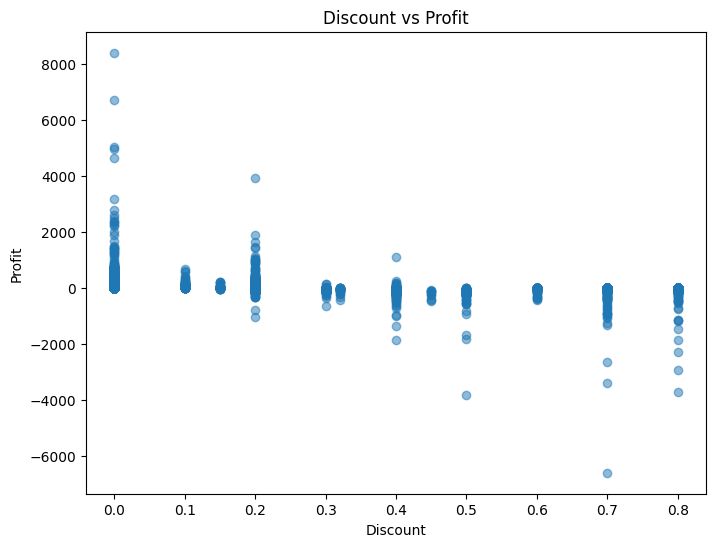

In [26]:
query = """
SELECT
    Discount,
    Profit
FROM Superstore;
"""

discount_profit = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,6))

plt.scatter(discount_profit["Discount"],
            discount_profit["Profit"],
            alpha=0.5)

plt.title("Discount vs Profit")

plt.xlabel("Discount")

plt.ylabel("Profit")

plt.show()

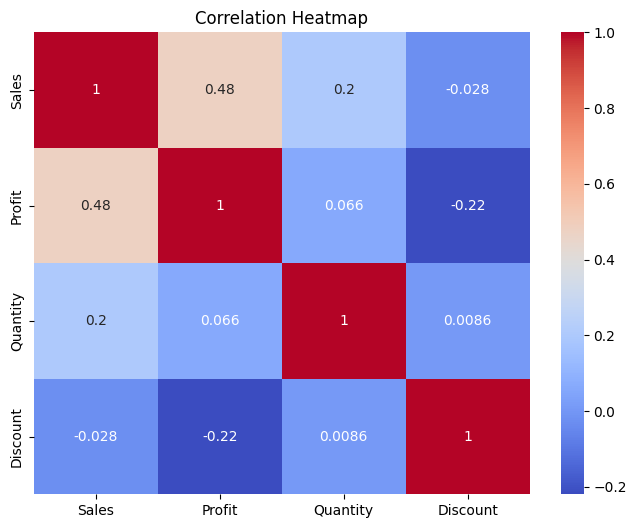

In [29]:
import seaborn as sns

query = """
SELECT
    Sales,
    Profit,
    Quantity,
    Discount
FROM Superstore;
"""

corr_df = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,6))

sns.heatmap(corr_df.corr(),
            annot=True,
            cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

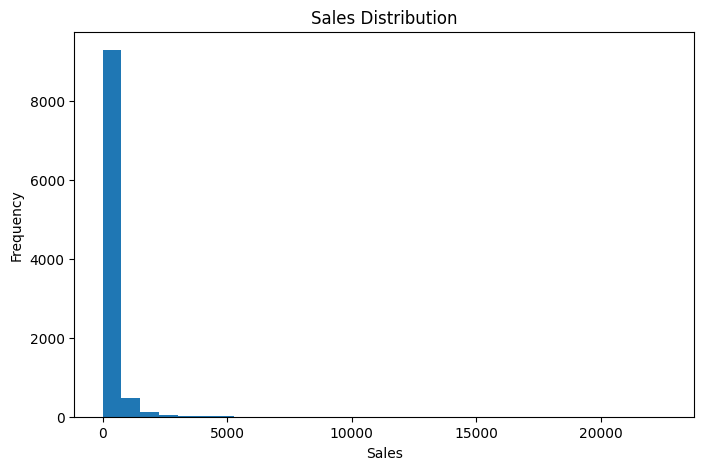

In [31]:
query = """
SELECT Sales
FROM Superstore;
"""

sales_dist = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.hist(sales_dist["Sales"],
         bins=30)

plt.title("Sales Distribution")

plt.xlabel("Sales")

plt.ylabel("Frequency")

plt.show()

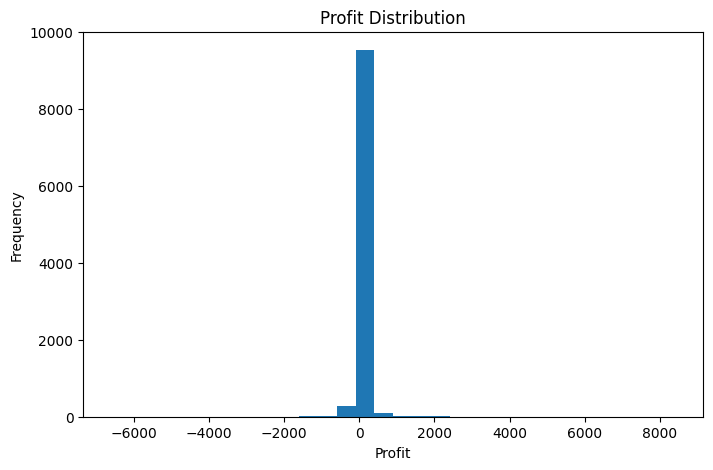

In [33]:
query = """
SELECT Profit
FROM Superstore;
"""

profit_dist = pd.read_sql_query(query, conn)

plt.figure(figsize=(8,5))

plt.hist(profit_dist["Profit"],
         bins=30)

plt.title("Profit Distribution")

plt.xlabel("Profit")

plt.ylabel("Frequency")

plt.show()